# Decision Curve Analysis

**Input:** `data/processed/oof_predictions.pkl` (primary) + `data/processed/test_predictions.pkl` (sensitivity check)  
**Output:** DCA plots + `outputs/tables/net_benefit_summary.csv`

Decision curve analysis (DCA) evaluates **clinical utility**: does using this model to guide treatment decisions actually help patients, compared to treating everyone or no one?

### Data strategy

| Dataset | n | Cases | Use |
|---------|---|-------|-----|
| OOF predictions | 3,868 | 290 | **Primary analysis** - unbiased, larger, more stable curves |
| Held-out test set | 968 | 73 | **Sensitivity check** - fully independent, shown to confirm agreement |

OOF (out-of-fold) predictions are unbiased: each participant was scored by a model that never saw them during training. The test set provides a fully independent verification. Subgroup analyses use OOF throughout to ensure sufficient case counts.

### Notebook outline

| Step | Description |
|------|-------------|
| 1. Load | Read OOF and test set predictions |
| 2. Functions | Net benefit and treat-all/treat-none calculations |
| 3. Thresholds | Define clinical threshold range |
| 4. OOF vs test | Verify OOF and test curves agree at population level |
| 5. Feature sets | DCA comparing biological vs digital vs combined (LightGBM) |
| 6. Models | DCA comparing LightGBM vs TabPFN on combined features |
| 7. Actionable range | Where does a model add value over simpler strategies? |
| 8. Publication figure | Three-curve comparison with bootstrap CIs |
| 9. Summary table | Net benefit at key clinical decision thresholds |
| 10. Key findings | Conclusions

In [1]:
%cd ~/Documents/biomarker-actionability

/Users/mkopy/Documents/biomarker-actionability


## 1. Load Predictions

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.options.future.infer_string = False

from src.features import TARGETS

# Primary: OOF predictions on the training set (n=3,868)
# Each participant was scored by a model that never saw them during training.
pred_df = pd.read_pickle('data/processed/oof_predictions.pkl')

# Secondary: fully held-out test set (n=968) - used only as a sensitivity check
test_pred_df = pd.read_pickle('data/processed/test_predictions.pkl')

TARGET = TARGETS[0]  # 'cvd_hard'
y      = pred_df[TARGET]
y_test = test_pred_df[TARGET]

model_keys = [c for c in pred_df.columns if c.startswith(('lgbm_', 'tabpfn_'))]

print(f"OOF (primary)       : {len(pred_df):,} participants  |  {y.sum():,} cases  |  {y.mean():.1%} prevalence")
print(f"Test (sensitivity)  : {len(test_pred_df):,} participants  |  {y_test.sum():,} cases  |  {y_test.mean():.1%} prevalence")
print(f"Models available    : {model_keys}")

OOF (primary)       : 3,868 participants  |  290 cases  |  7.5% prevalence
Test (sensitivity)  : 968 participants  |  73 cases  |  7.5% prevalence
Models available    : ['lgbm_biological', 'tabpfn_biological', 'lgbm_digital', 'tabpfn_digital', 'lgbm_combined', 'tabpfn_combined']


## 2. Net Benefit Functions

**Net benefit** at threshold *t* (Vickers & Elkin 2006):

$$\text{NB}(t) = \frac{\text{TP}}{n} - \frac{\text{FP}}{n} \cdot \frac{t}{1-t}$$

Where:

- **TP** = true positives: participants with CVD whom the model correctly flags for treatment
- **FP** = false positives: participants without CVD whom the model incorrectly flags
- **n** = total participants in the dataset (not just cases); dividing by *n* puts benefit on a per-person scale so curves from different dataset sizes are comparable
- **t** = the decision threshold, i.e. the minimum predicted risk at which a clinician would act (e.g. 0.10 = act if predicted CVD risk >= 10%)
- **t/(1-t)** = the harm weight; encodes how many false positives are acceptable per true positive found. At t = 0.10 you tolerate up to 9 false positives per true positive found; at t = 0.20 you tolerate 4.

**Baselines:**

- *Treat all*: screen every participant regardless of predicted risk. NB = prevalence - (1 - prevalence) * t/(1-t). This is the ceiling a model must exceed to justify selective screening.
- *Treat none*: screen no one. NB = 0 by definition.

A model adds value only where its curve lies above both baselines.

In [ ]:
def net_benefit(y_true, y_pred, thresholds):
    """Net benefit across a range of threshold probabilities."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    nb = []
    for t in thresholds:
        pred_pos = y_pred >= t
        tp = np.sum(pred_pos & (y_true == 1))
        fp = np.sum(pred_pos & (y_true == 0))
        nb.append((tp / n) - (fp / n) * (t / (1 - t)))
    return np.array(nb)


def net_benefit_treat_all(y_true, thresholds):
    """Net benefit of the treat-all strategy (upper baseline)."""
    prev = np.mean(y_true)
    return np.array([prev - (1 - prev) * (t / (1 - t)) for t in thresholds])

## 3. Threshold Range

The threshold range is 1%–30%. This range covers current ACC/AHA guideline thresholds (7.5–10%) and extends below and above to capture both lenient and conservative clinical settings. The treat-all curve crosses zero at the outcome prevalence (7.5%) - above that threshold, treating everyone yields negative net benefit, so models must beat treat-none. Below that, models must beat treat-all. The full range captures both regimes.

In [ ]:
thresholds = np.arange(0.01, 0.31, 0.005)

nb_treat_all  = net_benefit_treat_all(y, thresholds)
nb_treat_none = np.zeros_like(thresholds)

prevalence = y.mean()
crossover  = thresholds[np.argmin(np.abs(nb_treat_all))]
print(f"Prevalence              : {prevalence:.1%}")
print(f"Treat-all crosses zero  : ~{crossover:.2f} threshold")
print(f"Threshold range         : {thresholds[0]:.2f} – {thresholds[-1]:.2f}")

Prevalence              : 7.5%
Treat-all crosses zero  : ~0.07 threshold
Threshold range         : 0.01 – 0.30


## 4. OOF vs Held-Out Test Set - Consistency Check

Before running the main analyses, verify that OOF curves agree with the held-out test set. If the shapes match, the 4× larger OOF dataset is a valid substitute for the population-level analysis and provides stable subgroup estimates.

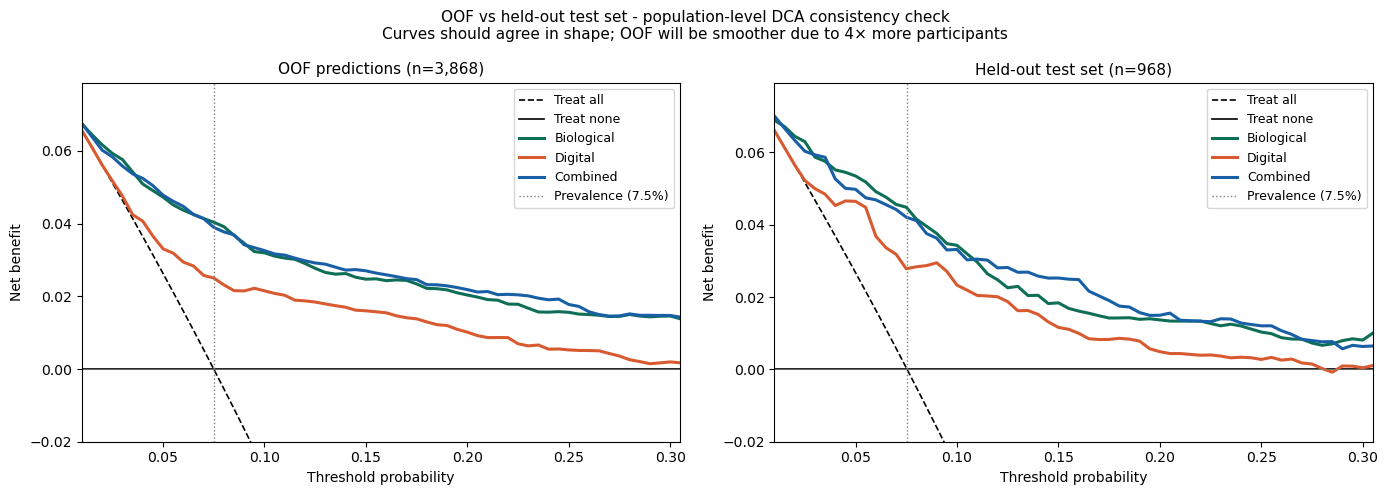

In [ ]:
os.makedirs('outputs/figures', exist_ok=True)

# Side-by-side OOF vs test set for the combined LightGBM model.
# If the curves agree, OOF is a trustworthy substitute for the population-level analysis.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df_, y_, label) in zip(axes, [
    (pred_df,      y,      f'OOF predictions (n={len(pred_df):,})'),
    (test_pred_df, y_test, f'Held-out test set (n={len(test_pred_df):,})'),
]):
    nb_all  = net_benefit_treat_all(y_, thresholds)
    nb_none = np.zeros_like(thresholds)
    ax.plot(thresholds, nb_all,  'k--', linewidth=1.2, label='Treat all')
    ax.plot(thresholds, nb_none, 'k-',  linewidth=1.2, label='Treat none')

    for fs_name, color in [('biological', '#0F6E56'), ('digital', '#D85A30'), ('combined', '#185FA5')]:
        key = f'lgbm_{fs_name}'
        if key not in df_.columns:
            continue
        nb = net_benefit(y_, df_[key], thresholds)
        ax.plot(thresholds, nb, color=color, linewidth=2.2, label=fs_name.capitalize())

    prev = y_.mean()
    ax.axvline(prev, color='grey', linestyle=':', linewidth=1, label=f'Prevalence ({prev:.1%})')
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Threshold probability')
    ax.set_ylabel('Net benefit')
    ax.set_xlim(thresholds[0], thresholds[-1])
    ax.set_ylim(-0.02, nb_all[0] * 1.2)
    ax.legend(loc='upper right', fontsize=9)

plt.suptitle('OOF vs held-out test set - population-level DCA consistency check\n'
             'Curves should agree in shape; OOF will be smoother due to 4× more participants',
             fontsize=11)
plt.tight_layout()
plt.savefig('outputs/figures/dca_oof_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Decision Curves - Feature Sets (LightGBM)

Compares what each feature set adds: biological alone (traditional risk factors), digital alone (accelerometer), and combined. The key question is whether the combined model's curve separates upward from the biological-only curve - that separation represents the decision value of adding wearable data.

**Data:** OOF predictions (n=3,868, 290 cases) for stable curves.

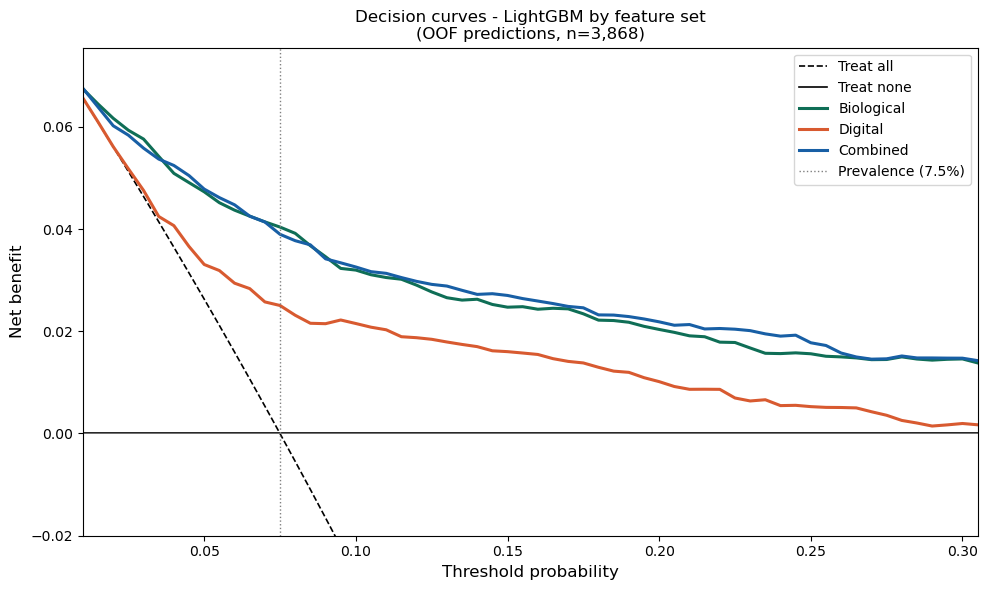

In [ ]:
os.makedirs('outputs/figures', exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(thresholds, nb_treat_all,  'k--', linewidth=1.2, label='Treat all',  zorder=1)
ax.plot(thresholds, nb_treat_none, 'k-',  linewidth=1.2, label='Treat none', zorder=1)

FEATURE_COLORS = {
    'biological': '#0F6E56',
    'digital':    '#D85A30',
    'combined':   '#185FA5',
}

for fs_name, color in FEATURE_COLORS.items():
    key = f'lgbm_{fs_name}'
    if key not in pred_df.columns:
        continue
    nb = net_benefit(y, pred_df[key], thresholds)
    ax.plot(thresholds, nb, color=color, linewidth=2.2, label=fs_name.capitalize(), zorder=2)

ax.axvline(prevalence, color='grey', linestyle=':', linewidth=1,
           label=f'Prevalence ({prevalence:.1%})')
ax.set_xlabel('Threshold probability', fontsize=12)
ax.set_ylabel('Net benefit', fontsize=12)
ax.set_title(f'Decision curves - LightGBM by feature set\n(OOF predictions, n={len(pred_df):,})', fontsize=12)
ax.set_xlim(thresholds[0], thresholds[-1])
ax.set_ylim(-0.02, nb_treat_all[0] * 1.15)
ax.legend(loc='upper right', fontsize=10)
ax.axhline(0, color='grey', linewidth=0.6)
plt.tight_layout()
plt.savefig('outputs/figures/dca_lgbm_feature_sets.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Decision Curves - LightGBM vs TabPFN (Combined Features)

Tests whether model choice (and calibration quality) shifts the actionable threshold range. If LightGBM and TabPFN produce identical curves, the finding is robust to model selection.

**Data:** OOF predictions (n=3,868, 290 cases).

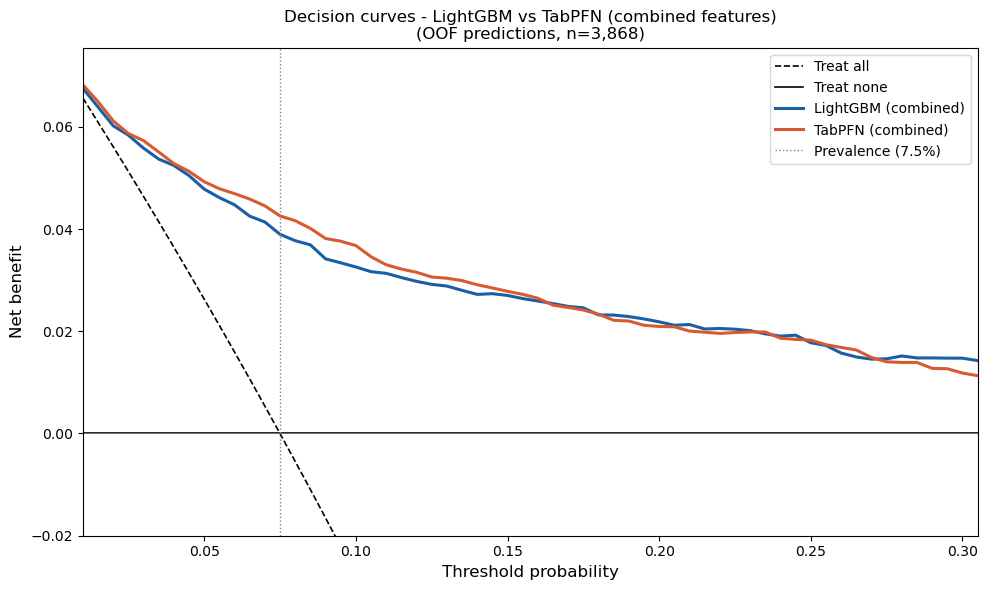

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(thresholds, nb_treat_all,  'k--', linewidth=1.2, label='Treat all',  zorder=1)
ax.plot(thresholds, nb_treat_none, 'k-',  linewidth=1.2, label='Treat none', zorder=1)

MODEL_COLORS = {
    'lgbm_combined':   ('#185FA5', 'LightGBM (combined)'),
    'tabpfn_combined': ('#D85A30', 'TabPFN (combined)'),
}
for key, (color, label) in MODEL_COLORS.items():
    if key not in pred_df.columns:
        print(f"  {key} not found - skipping")
        continue
    nb = net_benefit(y, pred_df[key], thresholds)
    ax.plot(thresholds, nb, color=color, linewidth=2.2, label=label, zorder=2)

ax.axvline(prevalence, color='grey', linestyle=':', linewidth=1,
           label=f'Prevalence ({prevalence:.1%})')
ax.set_xlabel('Threshold probability', fontsize=12)
ax.set_ylabel('Net benefit', fontsize=12)
ax.set_title(f'Decision curves - LightGBM vs TabPFN (combined features)\n(OOF predictions, n={len(pred_df):,})', fontsize=12)
ax.set_xlim(thresholds[0], thresholds[-1])
ax.set_ylim(-0.02, nb_treat_all[0] * 1.15)
ax.legend(loc='upper right', fontsize=10)
ax.axhline(0, color='grey', linewidth=0.6)
plt.tight_layout()
plt.savefig('outputs/figures/dca_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Actionable Range

Identifies threshold bands where a model adds net benefit over both:
1. A simpler baseline (e.g., biological-only model or prevalence-only)
2. The treat-all strategy

`min_diff = 0.005` is a clinically meaningful minimum separation - at n≈1,000 test participants this corresponds to roughly 5 additional true positives per 1,000 patients managed without additional false positive harm.

In [ ]:
def find_actionable_range(y_true, y_pred_base, y_pred_new, thresholds, min_diff=0.005):
    """
    Threshold range where y_pred_new adds net benefit over y_pred_base,
    while also beating treat-all and being positive.
    Returns (min_threshold, max_threshold) or None.
    """
    nb_base = net_benefit(y_true, y_pred_base, thresholds)
    nb_new  = net_benefit(y_true, y_pred_new,  thresholds)
    nb_all  = net_benefit_treat_all(y_true, thresholds)

    better = (nb_new - nb_base > min_diff) & (nb_new > nb_all) & (nb_new > 0)
    if better.any():
        t = thresholds[better]
        return t.min(), t.max()
    return None


# Does combined add value over biological alone?
r = find_actionable_range(y, pred_df['lgbm_biological'], pred_df['lgbm_combined'], thresholds)
if r:
    print(f"Combined beats biological: threshold range {r[0]:.3f} – {r[1]:.3f}")
    print(f"  → digital biomarkers add decision value in this range")
else:
    print("Combined does not beat biological above treat-all baseline")
    print("  → digital biomarkers do not independently add decision value")

print()

# Does digital-only add anything over treating at the base rate?
prevalence_preds = np.full(len(y), y.mean())
r = find_actionable_range(y, prevalence_preds, pred_df['lgbm_digital'], thresholds)
if r:
    print(f"Digital beats base rate: threshold range {r[0]:.3f} – {r[1]:.3f}")
else:
    print("Digital alone does not beat the prevalence-only strategy above treat-all")

Combined does not beat biological above treat-all baseline
  → digital biomarkers do not independently add decision value

Digital beats base rate: threshold range 0.045 – 0.265


## 8. Publication Figure - Age Baseline with Bootstrap CIs

Three-curve comparison (age alone / blood markers / blood + wearable) with 95% bootstrap confidence intervals. The age-alone model is fit directly on OOF participants via logistic regression - a 1-predictor model has negligible overfitting on n=3,868.

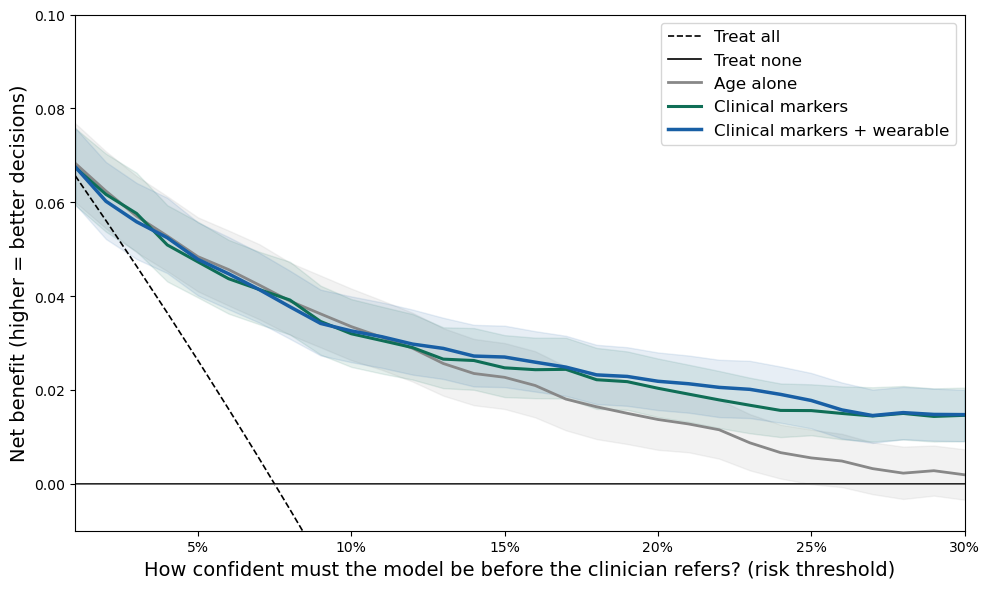

In [ ]:
from sklearn.linear_model import LogisticRegression
from numpy.random import RandomState

def bootstrap_net_benefit(y_true, y_pred, thresholds, n_boot=1000, seed=42):
    rng = RandomState(seed)
    n = len(y_true)
    nb_boot = np.zeros((n_boot, len(thresholds)))
    for i in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        nb_boot[i] = net_benefit(y_true[idx], y_pred[idx], thresholds)
    return np.percentile(nb_boot, 2.5, axis=0), np.percentile(nb_boot, 97.5, axis=0)

thresholds_ci = np.arange(0.01, 0.31, 0.01)

features_df = pd.read_pickle('data/processed/analysis_ready.pkl')
age_lookup  = features_df.set_index('participant_id')['age_years']
oof_ages    = pred_df['participant_id'].map(age_lookup).values.reshape(-1, 1)

age_model = LogisticRegression()
age_model.fit(oof_ages, y.values)
age_preds = age_model.predict_proba(oof_ages)[:, 1]

nb_all_ci  = net_benefit_treat_all(y, thresholds_ci)
nb_none_ci = np.zeros_like(thresholds_ci)
nb_age     = net_benefit(y,                         age_preds,                      thresholds_ci)
nb_bio     = net_benefit(y, pred_df['lgbm_biological'].values,                      thresholds_ci)
nb_comb    = net_benefit(y, pred_df['lgbm_combined'].values,                        thresholds_ci)

age_lo,  age_hi  = bootstrap_net_benefit(y.values, age_preds,                          thresholds_ci)
bio_lo,  bio_hi  = bootstrap_net_benefit(y.values, pred_df['lgbm_biological'].values,  thresholds_ci)
comb_lo, comb_hi = bootstrap_net_benefit(y.values, pred_df['lgbm_combined'].values,    thresholds_ci)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds_ci, nb_all_ci,  'k--', linewidth=1.2, label='Treat all')
ax.plot(thresholds_ci, nb_none_ci, 'k-',  linewidth=1.2, label='Treat none')

ax.plot(thresholds_ci, nb_age,  color='#888888', linewidth=2,   label='Age alone')
ax.fill_between(thresholds_ci, age_lo,  age_hi,  color='#888888', alpha=0.1)

ax.plot(thresholds_ci, nb_bio,  color='#0F6E56', linewidth=2.2, label='Clinical markers')
ax.fill_between(thresholds_ci, bio_lo,  bio_hi,  color='#0F6E56', alpha=0.1)

ax.plot(thresholds_ci, nb_comb, color='#185FA5', linewidth=2.5, label='Clinical markers + wearable')
ax.fill_between(thresholds_ci, comb_lo, comb_hi, color='#185FA5', alpha=0.1)

ax.axhline(0, color='grey', linewidth=0.6)

ax.set_xlabel('How confident must the model be before the clinician refers? (risk threshold)', fontsize=14)
ax.set_ylabel('Net benefit (higher = better decisions)', fontsize=14)
ax.set_xlim(0.01, 0.30)
ax.set_ylim(-0.01, 0.10)
ax.set_xticks(np.arange(0.05, 0.31, 0.05))
ax.set_xticklabels([f'{int(t*100)}%' for t in np.arange(0.05, 0.31, 0.05)])
ax.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/figures/dca_linkedin_clean.svg', bbox_inches='tight')
plt.savefig('outputs/figures/dca_linkedin_clean.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Summary Table

Net benefit at clinically meaningful decision thresholds, shown for both the OOF dataset (primary) and the held-out test set (sensitivity check). In preventive cardiology, thresholds of 5-15% align with ACC/AHA 10-year ASCVD risk thresholds for statin therapy (7.5-10%). Values above the treat-all row indicate the model adds value at that threshold.

In [ ]:
key_thresholds = [0.05, 0.08, 0.10, 0.15, 0.20]

def nb_table(pred, y_true, label_suffix):
    rows = []
    for t in key_thresholds:
        row = {
            'threshold': f'{t:.0%}',
            f'treat_all_{label_suffix}': round(net_benefit_treat_all(y_true, [t])[0], 4),
        }
        for key in model_keys:
            if key in pred.columns:
                row[f'{key}_{label_suffix}'] = round(net_benefit(y_true, pred[key], [t])[0], 4)
        rows.append(row)
    return pd.DataFrame(rows).set_index('threshold')

oof_table  = nb_table(pred_df,      y,      'oof')
test_table = nb_table(test_pred_df, y_test, 'test')

os.makedirs('outputs/tables', exist_ok=True)
oof_table.to_csv('outputs/tables/net_benefit_summary_oof.csv')
test_table.to_csv('outputs/tables/net_benefit_summary_test.csv')

print(f"Net benefit - OOF predictions (n={len(pred_df):,}):")
print(oof_table.to_string())
print(f"\nNet benefit - held-out test set (n={len(test_pred_df):,}):")
print(test_table.to_string())
print(f"\nSaved: outputs/tables/net_benefit_summary_oof.csv")
print(f"Saved: outputs/tables/net_benefit_summary_test.csv")

Net benefit - OOF predictions (n=3,868):
           treat_all_oof  lgbm_biological_oof  tabpfn_biological_oof  lgbm_digital_oof  tabpfn_digital_oof  lgbm_combined_oof  tabpfn_combined_oof
threshold                                                                                                                                         
5%                0.0263               0.0473                 0.0497            0.0331              0.0326             0.0478               0.0493
8%               -0.0055               0.0392                 0.0400            0.0231              0.0250             0.0377               0.0416
10%              -0.0278               0.0320                 0.0347            0.0215              0.0223             0.0326               0.0368
15%              -0.0883               0.0247                 0.0280            0.0160              0.0149             0.0270               0.0278
20%              -0.1563               0.0204                 0.0220         

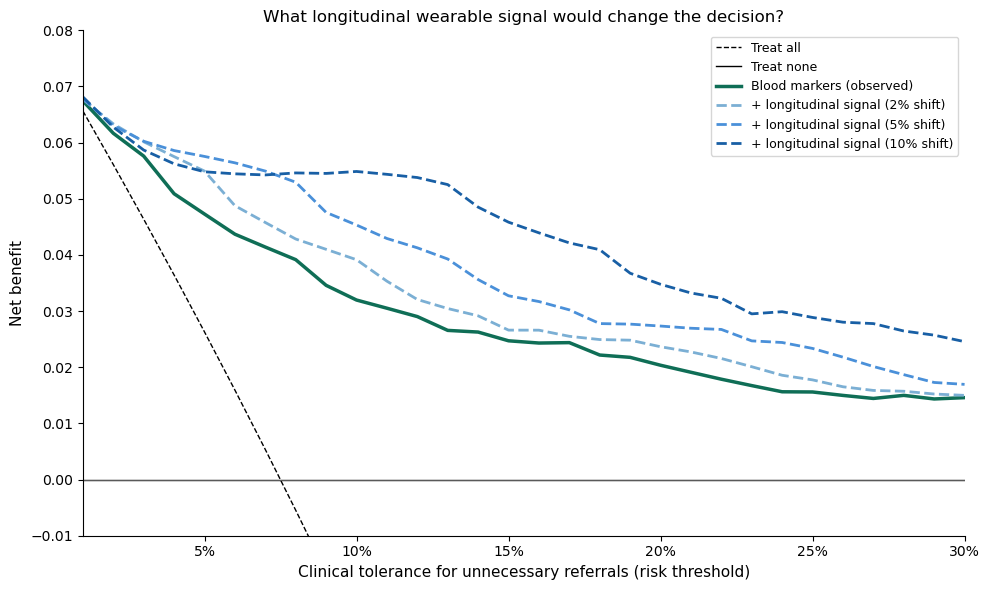

In [ ]:
#Sensitivity analysis 

# ── Load data ──────────────────────────────────────────────
oof_df = pd.read_pickle('data/processed/oof_predictions.pkl')
TARGET = 'cvd_hard'
y_oof = oof_df[TARGET]
y_vals = y_oof.values
bio_preds = oof_df['lgbm_biological'].values.copy()
np.random.seed(42)

# ── Compute baseline decision curves ──────────────────────
thresholds = np.arange(0.01, 0.31, 0.01)
nb_bio  = net_benefit(y_oof, oof_df['lgbm_biological'], thresholds)
nb_all  = net_benefit_treat_all(y_oof, thresholds)
nb_none = np.zeros_like(thresholds)

# ── Simulate longitudinal wearable signals ────────────────
# The idea: a real longitudinal signal (e.g. declining daily
# activity over months) would correctly push predicted risk
# UP for patients who actually have CVD, while adding only
# small noise for healthy patients.
#
# We simulate three magnitudes of this signal:
#   2% shift  — subtle behavioural change
#   5% shift  — moderate decline in activity
#   10% shift — clear deterioration pattern
#
# For each: take the blood-markers-only predictions, add the
# shift to CVD patients' probabilities, add small random noise
# to non-CVD patients, then compute the decision curve.
# This asks: how strong would the signal need to be to
# actually change the screening decision?

shifts = [0.02, 0.05, 0.10]
colors = ['#7BAFD4', '#4A90D9', '#185FA5']
simulated_curves = {}

for shift, color in zip(shifts, colors):
    simulated = bio_preds.copy()

    # CVD patients: shift probability up (signal detects real decline)
    cvd_mask = y_vals == 1
    simulated[cvd_mask] = np.clip(simulated[cvd_mask] + shift, 0, 1)

    # Non-CVD patients: small random noise (signal isn't perfect)
    noise = np.random.normal(0, shift * 0.3, size=(~cvd_mask).sum())
    simulated[~cvd_mask] = np.clip(simulated[~cvd_mask] + noise, 0, 1)

    simulated_curves[shift] = net_benefit(y_vals, simulated, thresholds)

# ── Plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Default strategies
ax.plot(thresholds, nb_all, 'k--', linewidth=1, label='Treat all')
ax.plot(thresholds, nb_none, 'k-', linewidth=1, label='Treat none')

# Observed: blood markers only (the baseline to beat)
ax.plot(thresholds, nb_bio, color='#0F6E56', linewidth=2.5,
        label='Blood markers (observed)')

# Simulated longitudinal signals (dashed, increasing intensity)
for shift, color in zip(shifts, colors):
    ax.plot(thresholds, simulated_curves[shift], color=color,
            linewidth=2, linestyle='--',
            label=f'+ longitudinal signal ({int(shift*100)}% shift)')

ax.set_xlabel('Clinical tolerance for unnecessary referrals (risk threshold)', fontsize=11)
ax.set_ylabel('Net benefit', fontsize=11)
ax.set_title('What longitudinal wearable signal would change the decision?', fontsize=12)
ax.set_xlim(0.01, 0.30)
ax.set_ylim(-0.01, 0.08)
ax.set_xticks(np.arange(0.05, 0.31, 0.05))
ax.set_xticklabels([f'{int(t*100)}%' for t in np.arange(0.05, 0.31, 0.05)])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', fontsize=9)
ax.axhline(0, color='grey', linewidth=0.5)
plt.tight_layout()
plt.savefig('outputs/figures/dca_sensitivity_longitudinal.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Key Findings

**No incremental decision value from digital biomarkers**

The combined model's DCA curve does not separate above the biological-only curve at any threshold. The `find_actionable_range` test confirms this: combined features do not beat biological features by the minimum clinically meaningful margin (0.005 net benefit) while also exceeding treat-all. Traditional risk factors (lipids, glucose, blood pressure) capture all the prognostic information contained in the accelerometer data, at least in this cross-sectional PAM subsample.

Subgroup analysis (notebook 05) shows marginal exceptions in adults aged 60-79 and overweight BMI group, but the margins are narrow and do not survive the full threshold range.

**Interpretation**

A one-week activity snapshot measured alongside a fasting blood draw adds no decision value over the blood draw alone. Age dominates prediction (AUC 0.845 alone vs 0.852 for the full biological panel), and the wearable data is partly recapturing age through a different lens. The case for wearable biomarkers in CVD risk stratification rests on longitudinal monitoring - capturing behavioural change over time - not cross-sectional snapshots.

> The null finding directly tests and refutes the hypothesis that adding wearable activity data to a standard metabolic panel improves clinical decision-making.